In [30]:
import glob, os, json, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import minimize

sns.set_context('talk')

In [31]:
#what makes good group performance?
#people positively influence each other?
#eg, blame less for partner's risky behavior?

#what makes ppl converge to risky choices that's within tolerance?

In [355]:
folder = "conf"
df_group = pd.read_csv(f'../processed_data/parsed_group_{folder}.csv')
# df_group['finalStep'] = np.ceil(df_group['finalStep']/2).astype(int)
df_idv = pd.read_csv(f'../processed_data/parsed_idv_{folder}.csv')
# qs = pd.read_csv('../processed_data/parsed_questionnaire_all.csv')
df_group = df_group.sort_values(by=['room', 'predatorType', 'trial']).reset_index(drop=True)
df_group['prediction_next'] = df_group.groupby(['subID', 'predatorType'])['prediction'].shift(-1)


In [240]:
df_group.head()

,attack,selfBlame,jointMoney,partnerStep,playerStep,predatorAttack,prediction,playerKeep,split_rt,step_rt,...,confidence,predatorType,finalStep,player_partner_diff,playerKeep2,payoff,sub_full,subID,remap_subID,prediction_next
0,True,0.75,-20,4,7,0,7,0.25,3.269600,6.538898,...,70,0,6,3,0.75,-5,5c2c0cd5da51990001e3d529,0,0,5.0
1,True,0.25,-20,7,4,0,4,0.50,2.082900,1.949800,...,70,0,6,-3,0.50,-10,65a04a6bb11a9bdf067755d0,1,1,4.0
2,False,0.75,50,4,5,0,5,0.75,1.568200,2.151800,...,70,0,5,1,0.75,38,5c2c0cd5da51990001e3d529,0,0,5.0
3,False,0.50,50,5,4,0,4,0.50,1.082500,3.349999,...,70,0,5,-1,0.50,25,65a04a6bb11a9bdf067755d0,1,1,4.0
4,False,0.75,50,4,5,0,5,1.00,1.751301,1.834400,...,70,0,5,1,1.00,50,5c2c0cd5da51990001e3d529,0,0,5.0


In [241]:
df_group.columns

Index(['attack', 'selfBlame', 'jointMoney', 'partnerStep', 'playerStep',
       'predatorAttack', 'prediction', 'playerKeep', 'split_rt', 'step_rt',
       'trial', 'sub', 'room', 'block', 'playerID', 'confidence',
       'predatorType', 'finalStep', 'player_partner_diff', 'playerKeep2',
       'payoff', 'sub_full', 'subID', 'remap_subID', 'prediction_next'],
      dtype='object')

(array([48., 72., 63., 43., 12.,  7.,  1.,  1.,  2.,  1.]),
 array([0.08333333, 0.63333333, 1.18333333, 1.73333333, 2.28333333,
        2.83333333, 3.38333333, 3.93333333, 4.48333333, 5.03333333,
        5.58333333]),
 <BarContainer object of 10 artists>)

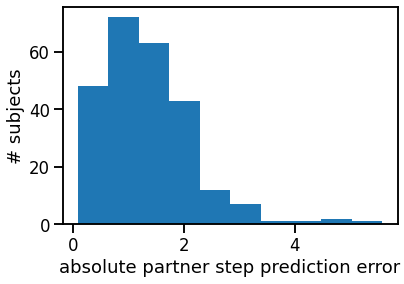

In [242]:
# check prediction error between prediction and partner step. compare people with high vs low prediction error
df_group['pred_error'] = np.abs(df_group['prediction'] - df_group['partnerStep'])
# df_group['pred_error_bin'] = pd.qcut(df_group['pred_error'], q=3, labels=['low', 'med', 'high'])
d = df_group.query('prediction>0').groupby('subID')['pred_error'].mean().reset_index()
plt.xlabel('absolute partner step prediction error')
plt.ylabel('# subjects')
plt.hist(d['pred_error'])

# Model fit

In [243]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar


class PartnerPredictionModel:
    """
    model_type options
    ------------------
    1: Model A Scalar RW
       mu_t+1 = mu_t + eta * (partnerStep_t - mu_t)

    2: Model B 
       Learn alpha and beta with the same learning rate
       mu_t+1 = partnerStep_t + alpha_t * attack_t + beta_t * player_partner_diff_t
       alpha_t+1 = alpha_t + eta * (partnerStep_t+1 - mu_t+1) * attack_t
       beta_t+1  = beta_t  + eta * (partnerStep_t+1 - mu_t+1) * player_partner_diff_t

    3: Model C 
       Fix alpha = -1, learn beta only
       mu_t+1 = partnerStep_t - attack_t + beta_t * player_partner_diff_t
       beta_t+1 = beta_t + eta * (partnerStep_t+1 - mu_t+1) * player_partner_diff_t

    4. Model D (win-stay-lose-shift)
    
    """

    def __init__(
        self,
        model_type=1,
        n_squares=9,
        beta0=0.0,
        alpha0=0.0,
        eta=0.05,
        sigma=1.0,
        mu0=5,
    ):
        self.model_type = model_type
        self.n_squares = n_squares
        self.beta = beta0
        self.alpha = alpha0
        self.eta = eta
        self.sigma = sigma
        self.mu = mu0


    def _clip_square(self, x):
        return float(np.clip(x, 1, self.n_squares))

    def expected_step(self, partner_step_prev, attack_prev, player_partner_diff_prev):
        if self.model_type == 1:
            if self.mu is None:
                self.mu = float(partner_step_prev)
            mu_t = self.mu + self.eta * (partner_step_prev - self.mu)
        elif self.model_type == 2:
            mu_t = partner_step_prev + self.alpha * attack_prev + self.beta * player_partner_diff_prev
           
        elif self.model_type == 3:
            mu_t = partner_step_prev - attack_prev + self.beta * player_partner_diff_prev
        
        elif self.model_type == 4:
            direction = 1 - 2 * attack_prev
            mu_t = partner_step_prev + self.beta * direction
        return self._clip_square(mu_t)

    def get_probs(self, mu):
        squares = np.arange(1, self.n_squares + 1)
        logits = -((squares - mu) ** 2) / (2 * self.sigma ** 2)
        logits -= np.max(logits)
        probs = np.exp(logits)
        probs /= probs.sum()
        return probs

    def update(self, partner_step_prev, attack_prev, player_partner_diff_prev, partner_step_t):
        mu_t = self.expected_step(partner_step_prev, attack_prev, player_partner_diff_prev)
        delta = partner_step_t - mu_t
        
        if self.model_type == 1:
            self.mu = mu_t

        elif self.model_type == 2:
            self.alpha += self.eta * delta * attack_prev
            self.beta += self.eta * delta * player_partner_diff_prev

        elif self.model_type == 3:
            self.beta += self.eta * delta * player_partner_diff_prev
            
        else:
            direction = 1 - 2 * attack_prev
            self.beta += self.eta * delta * direction

        return mu_t, delta
    

    def choose_prediction(self, probs, mode="sample"):
        squares = np.arange(1, self.n_squares + 1)
        if mode == "sample":
            return int(np.random.choice(squares, p=probs))
        elif mode == "argmax":
            return int(squares[np.argmax(probs)])
        elif mode == "mean_round":
            return int(np.clip(np.round(np.sum(squares * probs)), 1, self.n_squares))
        else:
            raise ValueError("mode must be 'sample', 'argmax', or 'mean_round'")


In [244]:

def compute_subject_loglik(
    g,
    model_type,
    eta,
    sigma,
    beta0=0.0,
    alpha0=0.0,
    mu0=None,
    n_squares=9,
):
    """
    Compute log-likelihood of one subject's observed predictions
    under given eta and sigma.
    """
    g = g.sort_values(["predatorType", "trial"]).reset_index(drop=True)

    loglik = 0.0
    n_used = 0

    # fit separately within each predator block/sequence
    for predator, gp in g.groupby("predatorType", sort=False):
        gp = gp.sort_values("trial").reset_index(drop=True)

        model = PartnerPredictionModel(
            model_type=model_type,
            n_squares=n_squares,
            beta0=beta0,
            alpha0=alpha0,
            eta=eta,
            sigma=sigma,
            mu0=mu0,
        )

        for t in range(len(gp)):
            row_t = gp.iloc[t]

            # skip missing observed prediction
            pred_obs = row_t['prediction_next']
            if pd.isna(pred_obs):
                continue

            partner_step_t = row_t["partnerStep"]
            attack_t = row_t["attack"]
            diff_t = row_t["player_partner_diff"]

            # make a prediction for next round
            mu = model.expected_step(partner_step_t, attack_t, diff_t)
            probs_t = model.get_probs(mu)

            pred_obs = int(pred_obs)
            if pred_obs < 1 or pred_obs > n_squares:
                continue

            loglik += np.log(probs_t[pred_obs - 1] + 1e-12)
            n_used += 1

            # update using actual next partner behavior, if next trial exists
            if t < len(gp) - 1:
                partner_step_next = gp.loc[t + 1, "partnerStep"]
                model.update(
                    partner_step_prev=partner_step_t,
                    attack_prev=attack_t,
                    player_partner_diff_prev=diff_t,
                    partner_step_t=partner_step_next,
                )

    return loglik, n_used


def fit_eta_sigma_one_subject(
    g,
    model_type,
    beta0=0.0,
    alpha0=0.0,
    mu0=None,
    n_squares=9,
    eta_bounds=(0.0, 1.0),
    sigma_bounds=(1e-3, 10.0),
    eta_init=0.1,
    sigma_init=1.0,
):
    """
    Estimate best-fitting eta and sigma for one participant
    by maximizing log-likelihood.
    """

    if model_type == 3:
        eta_bounds=(0.0, 1.0)
        
    def objective(params):
        eta, sigma = params

        loglik, n_used = compute_subject_loglik(
            g=g,
            model_type=model_type,
            eta=eta,
            sigma=sigma,
            beta0=beta0,
            alpha0=alpha0,
            mu0=mu0,
            n_squares=n_squares,
        )

        # minimize negative log-likelihood
        return -loglik


    res = minimize(
        objective,
        x0=np.array([eta_init, sigma_init]),
        bounds=[eta_bounds, sigma_bounds],
        method="L-BFGS-B",
    )

    best_eta, best_sigma = res.x
    best_loglik, n_used = compute_subject_loglik(
        g=g,
        model_type=model_type,
        eta=best_eta,
        sigma=best_sigma,
        beta0=beta0,
        alpha0=alpha0,
        mu0=mu0,
        n_squares=n_squares,
    )

    k = 2  # eta and sigma
    aic = 2 * k - 2 * best_loglik if n_used > 0 else np.nan
    bic = k * np.log(n_used) - 2 * best_loglik if n_used > 0 else np.nan

    return {
        "eta_hat": best_eta,
        "sigma_hat": best_sigma,
        "loglik": best_loglik,
        "n_obs": n_used,
        "AIC": aic,
        "BIC": bic,
        # "success": res.success,
    }


def fit_eta_sigma_all_subjects(
    df,
    model_type,
    beta0=0.0,
    alpha0=0.0,
    mu0=None,
    n_squares=9,
    eta_bounds=(0.0, 1.0),
    sigma_bounds=(1e-3, 10.0),
    eta_init=0.1,
    sigma_init=1.0,
):
    """
    Fit best eta and sigma for each participant (subID).
    """

    # if model_type == 1:
    #     eta_bounds=(0.0, 1.0)
    required_cols = [
        "subID", "predatorType", "trial",
        "partnerStep", "attack", "player_partner_diff", "prediction"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    results = []

    for sub, g in df.groupby("subID", sort=False):
        out = fit_eta_sigma_one_subject(
            g=g,
            model_type=model_type,
            beta0=beta0,
            alpha0=alpha0,
            mu0=mu0,
            n_squares=n_squares,
            eta_bounds=eta_bounds,
            sigma_bounds=sigma_bounds,
            eta_init=eta_init,
            sigma_init=sigma_init,
        )

        results.append({
            "subID": sub,
            "model_type": model_type,
            **out
        })

    return pd.DataFrame(results)

In [245]:

fit_A = fit_eta_sigma_all_subjects(
    df_group,
    model_type=1,
)

In [246]:
fit_B = fit_eta_sigma_all_subjects(
    df_group,
    model_type=2,
)

In [247]:
fit_C = fit_eta_sigma_all_subjects(
    df_group,
    model_type=3,
)

In [248]:
fit_D = fit_eta_sigma_all_subjects(
    df_group,
    model_type=4,
)

In [251]:
from functools import reduce

fits = {
    "standard": fit_A,
    "ppd": fit_B,
    "ppdAttack": fit_C,
    "wflb": fit_D,
}

df_flat = reduce(
    lambda left, right: pd.merge(left, right, on="subID", how="inner"),
    [
        df[["subID", "loglik", "AIC", "BIC", "eta_hat", "sigma_hat"]].rename(
            columns={
                "loglik": f"loglik_{name}",
                "AIC": f"AIC_{name}",
                "BIC": f"BIC_{name}",
                "eta_hat":f"eta_{name}",
                "sigma_hat":f"sigma_{name}",
            }
        )
        for name, df in fits.items()
    ],
)


In [252]:
df_flat.to_csv(f'../model_fits/rl_{folder}/prediction_model_fits.csv')
print(len(df_flat.subID.unique()))
df_flat.head()

250


,subID,loglik_standard,AIC_standard,BIC_standard,eta_standard,sigma_standard,loglik_ppd,AIC_ppd,BIC_ppd,eta_ppd,...,loglik_ppdAttack,AIC_ppdAttack,BIC_ppdAttack,eta_ppdAttack,sigma_ppdAttack,loglik_wflb,AIC_wflb,BIC_wflb,eta_wflb,sigma_wflb
0,0,-34.551991,73.103982,77.224868,0.418582,0.464024,-41.264600,86.529200,90.650086,0.128155,...,-51.458117,106.916234,111.037120,0.217503,0.589571,-43.626450,91.252900,95.373786,0.000000,0.531363
1,1,-56.676144,117.352287,121.473173,0.945630,0.645381,-49.390771,102.781543,106.902429,0.130010,...,-57.406062,118.812124,122.933010,0.118188,0.652547,-56.740802,117.481604,121.602490,0.000000,0.646090
2,2,-85.545007,175.090013,179.176116,1.000000,1.345703,-85.545007,175.090013,179.176116,0.000000,...,-78.316847,160.633695,164.719797,0.000000,1.117309,-80.695183,165.390366,169.476469,0.147230,1.195149
3,3,-82.233309,168.466618,172.587504,0.616821,1.105814,-83.416684,170.833368,174.954254,0.010507,...,-77.591051,159.182103,163.302989,0.007681,1.005365,-76.913702,157.827405,161.948291,0.159377,0.992694
4,4,-79.835994,163.671989,167.758091,0.190430,1.302560,-95.685204,195.370409,199.456511,0.000000,...,-99.405192,202.810385,206.896487,0.000000,2.004673,-95.685204,195.370409,199.456511,0.000000,2.059958


## plot BIC

In [253]:
# folder = 'conf'
if folder == 'conf':
    df_flat1 = pd.read_csv(f'../model_fits/rl_conf/prediction_model_fits.csv')
    df_flat2 = pd.read_csv(f'../model_fits/rl_rep2/prediction_model_fits.csv')
    df_flat2['subID'] = df_flat2['subID'] + 400
    df_flat = pd.concat([df_flat1, df_flat2])
elif folder=='expl':
    df_flat = pd.read_csv(f'../model_fits/rl_expl/prediction_model_fits.csv')


print(len(df_flat.subID.unique()))
df_flat.head()

250


,Unnamed: 0,subID,loglik_standard,AIC_standard,BIC_standard,eta_standard,sigma_standard,loglik_ppd,AIC_ppd,BIC_ppd,...,loglik_ppdAttack,AIC_ppdAttack,BIC_ppdAttack,eta_ppdAttack,sigma_ppdAttack,loglik_wflb,AIC_wflb,BIC_wflb,eta_wflb,sigma_wflb
0,0,0,-34.551991,73.103982,77.224868,0.418582,0.464024,-41.264600,86.529200,90.650086,...,-51.458117,106.916234,111.037120,0.217503,0.589571,-43.626450,91.252900,95.373786,0.000000,0.531363
1,1,1,-56.676144,117.352287,121.473173,0.945630,0.645381,-49.390771,102.781543,106.902429,...,-57.406062,118.812124,122.933010,0.118188,0.652547,-56.740802,117.481604,121.602490,0.000000,0.646090
2,2,2,-85.545007,175.090013,179.176116,1.000000,1.345703,-85.545007,175.090013,179.176116,...,-78.316847,160.633695,164.719797,0.000000,1.117309,-80.695183,165.390366,169.476469,0.147230,1.195149
3,3,3,-82.233309,168.466618,172.587504,0.616821,1.105814,-83.416684,170.833368,174.954254,...,-77.591051,159.182103,163.302989,0.007681,1.005365,-76.913702,157.827405,161.948291,0.159377,0.992694
4,4,4,-79.835994,163.671989,167.758091,0.190430,1.302560,-95.685204,195.370409,199.456511,...,-99.405192,202.810385,206.896487,0.000000,2.004673,-95.685204,195.370409,199.456511,0.000000,2.059958


/var/folders/pz/7dj8ydn13nl3v61r2ph397lh0000gn/T/ipykernel_54982/1230701880.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


standard RW vs ppd: stat=2658.0, p=1.2912268607504495e-29, mean delta BIC=-17.118055267266858
standard RW vs wflb: stat=906.0, p=1.2941173325187292e-37, mean delta BIC=-19.974419810035158
standard RW vs ppdAttack: stat=1045.0, p=1.7787283926398093e-37, mean delta BIC=-24.487212653574222
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

standard vs. ppd: Wilcoxon test (paired samples), P_val:1.291e-29 Stat=2.658e+03
standard vs. wflb: Wilcoxon test (paired samples), P_val:1.294e-37 Stat=9.060e+02
standard vs. ppdAttack: Wilcoxon test (paired samples), P_val:1.779e-37 Stat=1.045e+03


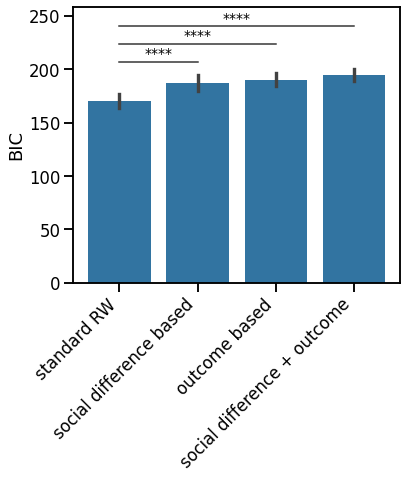

In [254]:
# plot bic

df_long = df_flat.melt(id_vars="subID", value_vars=["BIC_standard", "BIC_ppd", "BIC_wflb", "BIC_ppdAttack"], 
                         var_name="model", value_name="BIC")

plt.figure(figsize=(6, 7))
ax = sns.barplot(df_long, x="model", y="BIC")
ax.set_xticklabels(
    ['standard RW', 
     'social difference based', 
     'outcome based',
     'social difference + outcome', 
     ],
    rotation=45,
    ha='right'
)
ax.set_xlabel('')

# test significance of deltaBIC between models A and C, and between B and C
from scipy.stats import wilcoxon
for num in ["ppd", "wflb", "ppdAttack"]:
    df_flat[f"delta_standard_{num}"] = df_flat["BIC_standard"] - df_flat[f"BIC_{num}"]
    stat_A, p_A = wilcoxon(df_flat[f"delta_standard_{num}"]) # A vs {num}
    print(f"standard RW vs {num}: stat={stat_A}, p={p_A}, mean delta BIC={df_flat[f'delta_standard_{num}'].mean()}")

# annotate significance on plot: use annotate package
from statannotations.Annotator import Annotator
df_long["model"] = df_long["model"].str.replace("BIC_", "")
pairs = [
    ("standard", "ppd"),
    ("standard", "wflb"),
    ("standard", "ppdAttack"),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="model",
    y="BIC"
)

annotator.configure(
    test="Wilcoxon",
    text_format="star",   # or "simple"
    loc="inside",
    verbose=2,
    fontsize=14,
    line_height = 0
)

annotator.apply_and_annotate()
plt.tight_layout()
plt.savefig(f'../paper_figs/{folder}/add_prediction_model_bic_{folder}.png', 
            bbox_inches='tight', dpi=200)

# Model Simulation

In [255]:
def simulate_predictions(
    df,
    params_df,
    model_type,
    n_squares=9,
    choice_mode="sample",
    default_eta=0.05,
    default_beta0=0.0,
    default_alpha0=0.0,
    default_mu0=None,
    default_sigma=1.0,
):
    """
    Simulate trial-by-trial predictions using each subject's fitted parameters.

    Parameters
    ----------
    df : pd.DataFrame
        Trial-level data. Must contain:
        subID, predatorType, trial, partnerStep, attack, player_partner_diff
        Optional: prediction

    params_df : pd.DataFrame
        Subject-level parameter table. Must contain:
        subID
        Optional fitted columns:
            eta_hat, beta0_hat, alpha0_hat, mu0_hat, sigma_hat

    model_type : int
        1, 2, or 3

    Returns
    -------
    sim_df : pd.DataFrame
        Trial-level simulated predictions and latent states
    """
    required_cols = ["subID", "predatorType", "trial", "partnerStep", "attack", "player_partner_diff"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in df: {missing}")

    if "subID" not in params_df.columns:
        raise ValueError("params_df must contain 'subID'")

    df = df.copy()
    params_df = params_df.copy()

    # merge subject-level params into trial-level df
    merged = df.merge(params_df, on="subID", how="left")
    merged = merged.sort_values(["subID", "predatorType", "trial"]).reset_index(drop=True)

    all_rows = []

    for i, ((sub, predator), g) in enumerate(merged.groupby(["subID", "predatorType"], sort=False)):
        g = g.sort_values("trial").reset_index(drop=True)


        # pull subject-specific fitted params if available
        first_row = g.iloc[0]

        eta_sub = first_row["eta_hat"] if "eta_hat" in g.columns and pd.notna(first_row["eta_hat"]) else default_eta
        beta0_sub = first_row["beta0_hat"] if "beta0_hat" in g.columns and pd.notna(first_row["beta0_hat"]) else default_beta0
        alpha0_sub = first_row["alpha0_hat"] if "alpha0_hat" in g.columns and pd.notna(first_row["alpha0_hat"]) else default_alpha0
        mu0_sub = first_row["mu0_hat"] if "mu0_hat" in g.columns and pd.notna(first_row["mu0_hat"]) else default_mu0
        sigma_sub = first_row["sigma_hat"] if "sigma_hat" in g.columns and pd.notna(first_row["sigma_hat"]) else default_sigma

        model = PartnerPredictionModel(
            model_type=model_type,
            n_squares=n_squares,
            beta0=beta0_sub,
            alpha0=alpha0_sub,
            eta=eta_sub,
            sigma=sigma_sub,
            mu0=mu0_sub,
            # random_state=random_state + i,
        )

        for t in range(len(g)):
            row_t = g.iloc[t]

            partner_step_t = row_t["partnerStep"]
            attack_t = row_t["attack"]
            diff_t = row_t["player_partner_diff"]

            if pd.isna(partner_step_t) or pd.isna(attack_t) or pd.isna(diff_t):
                continue

            alpha_before = model.alpha if model_type in [2, 3, 4] else np.nan
            beta_before = model.beta if model_type in [2, 3, 4] else np.nan
            mu_state_before = model.mu if model_type == 1 else np.nan

            mu_t = model.expected_step(partner_step_t, attack_t, diff_t)
            probs_t = model.get_probs(mu_t)
            pred_sim = model.choose_prediction(probs_t, mode=choice_mode)

            rec = {
                "subID": sub,
                "predatorType": predator,
                "trial": row_t["trial"],
                "model_type": model_type,

                # fitted params actually used
                "eta_used": eta_sub,
                # "beta0_used": beta0_sub,
                # "alpha0_used": alpha0_sub,
                "mu0_used": mu0_sub,
                "sigma_used": sigma_sub,

                # trial inputs
                "partnerStep_t": partner_step_t,
                "attack_t": attack_t,
                "player_partner_diff_t": diff_t,

                # latent state before update
                "alpha_before": alpha_before,
                "beta_before": beta_before,
                "mu_state_before": mu_state_before,

                # current prediction distribution
                "mu_pred": mu_t,
                "prediction_sim": pred_sim,
                "prediction_argmax": int(np.argmax(probs_t) + 1),
            }

            if "prediction" in g.columns:
                rec["prediction_obs"] = row_t["prediction"]
                pred_obs = row_t["prediction"]
                if pd.notna(pred_obs) and 1 <= int(pred_obs) <= n_squares:
                    rec["loglik_prediction_obs"] = np.log(probs_t[int(pred_obs) - 1] + 1e-12)
                else:
                    rec["loglik_prediction_obs"] = np.nan

            for k, p in enumerate(probs_t, start=1):
                rec[f"p_square_{k}"] = p

            # update using actual next partner behavior if next trial exists
            if t < len(g) - 1:
                partner_step_next = g.loc[t + 1, "partnerStep"]

                _, delta_t = model.update(
                    partner_step_prev=partner_step_t,
                    attack_prev=attack_t,
                    player_partner_diff_prev=diff_t,
                    partner_step_t=partner_step_next,
                )

                rec["partnerStep_next"] = partner_step_next
                rec["delta"] = delta_t
                # rec["alpha_after"] = state_after["alpha"] if state_after["alpha"] is not None else np.nan
                # rec["beta_after"] = state_after["beta"] if state_after["beta"] is not None else np.nan
                # rec["mu_state_after"] = state_after["mu"] if state_after["mu"] is not None else np.nan

            else:
                rec["partnerStep_next"] = np.nan
                rec["delta"] = np.nan
                # rec["alpha_after"] = model.alpha if model_type == 2 else (-1.0 if model_type == 1 else np.nan)
                # rec["beta_after"] = model.beta if model_type in [1, 2] else np.nan
                # rec["mu_state_after"] = model.mu if model_type == 3 else np.nan

            all_rows.append(rec)

    return pd.DataFrame(all_rows)

In [256]:
sim_A = simulate_predictions(
    df=df_group,
    params_df=fit_A,
    model_type=1,
    choice_mode="sample",
    default_beta0=0.0,

    
    default_sigma=1.0
)
sim_A.head()

,subID,predatorType,trial,model_type,eta_used,mu0_used,sigma_used,partnerStep_t,attack_t,player_partner_diff_t,...,p_square_2,p_square_3,p_square_4,p_square_5,p_square_6,p_square_7,p_square_8,p_square_9,partnerStep_next,delta
0,0,0,1,1,0.418582,None,0.464024,4,True,3,...,0.000077,0.081971,0.835902,0.081971,0.000077,7.010040e-10,6.113234e-17,5.126677e-26,4.0,0.0
1,0,0,2,1,0.418582,None,0.464024,4,False,1,...,0.000077,0.081971,0.835902,0.081971,0.000077,7.010040e-10,6.113234e-17,5.126677e-26,4.0,0.0
2,0,0,3,1,0.418582,None,0.464024,4,False,1,...,0.000077,0.081971,0.835902,0.081971,0.000077,7.010040e-10,6.113234e-17,5.126677e-26,4.0,0.0
3,0,0,4,1,0.418582,None,0.464024,4,False,1,...,0.000077,0.081971,0.835902,0.081971,0.000077,7.010040e-10,6.113234e-17,5.126677e-26,4.0,0.0
4,0,0,5,1,0.418582,None,0.464024,4,True,1,...,0.000077,0.081971,0.835902,0.081971,0.000077,7.010040e-10,6.113234e-17,5.126677e-26,4.0,0.0


In [257]:
sim_B = simulate_predictions(
    df=df_group,
    params_df=fit_B,
    model_type=2,
    choice_mode="sample",
    default_beta0=0.0,
    default_sigma=1.0
)

In [258]:
sim_C = simulate_predictions(
    df=df_group,
    params_df=fit_C,
    model_type=3,
    choice_mode="sample",
    default_beta0=0.0,
    default_sigma=1.0
)


In [259]:
sim_D = simulate_predictions(
    df=df_group,
    params_df=fit_C,
    model_type=4,
    choice_mode="sample",
    default_beta0=0.0,
    default_sigma=1.0
)
sim_C.head()

,subID,predatorType,trial,model_type,eta_used,mu0_used,sigma_used,partnerStep_t,attack_t,player_partner_diff_t,...,p_square_2,p_square_3,p_square_4,p_square_5,p_square_6,p_square_7,p_square_8,p_square_9,partnerStep_next,delta
0,0,0,1,3,0.217503,None,0.589571,4,True,3,...,0.160232,0.675252,0.160232,0.002141,0.000002,6.823759e-11,1.627750e-16,2.186358e-23,4.0,1.000000
1,0,0,2,3,0.217503,None,0.589571,4,False,1,...,0.000027,0.013333,0.367210,0.569459,0.049726,2.444945e-04,6.769036e-08,1.055248e-12,4.0,-0.652508
2,0,0,3,3,0.217503,None,0.589571,4,False,1,...,0.000078,0.025454,0.466037,0.480449,0.027890,9.116105e-05,1.677819e-08,1.738803e-13,4.0,-0.510586
3,0,0,4,3,0.217503,None,0.589571,4,False,1,...,0.000171,0.040503,0.538751,0.403516,0.017018,4.041241e-05,5.403764e-09,4.068626e-14,4.0,-0.399532
4,0,0,5,3,0.217503,None,0.589571,4,True,1,...,0.056798,0.588388,0.343211,0.011273,0.000021,2.171067e-09,1.273063e-14,4.203358e-21,4.0,0.687367


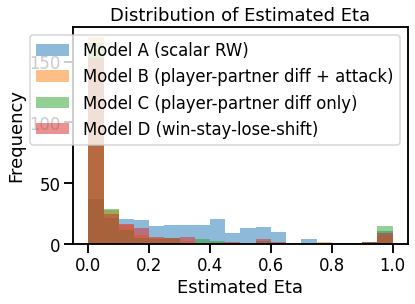

In [260]:
plt.hist(fit_A['eta_hat'], bins=20, alpha=0.5, label='Model A (scalar RW)')
plt.hist(fit_B['eta_hat'], bins=20, alpha=0.5, label='Model B (player-partner diff + attack)')
plt.hist(fit_C['eta_hat'], bins=20, alpha=0.5, label='Model C (player-partner diff only)')
plt.hist(fit_D['eta_hat'], bins=20, alpha=0.5, label='Model D (win-stay-lose-shift)')
plt.xlabel('Estimated Eta')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Eta')
plt.legend()
plt.show()

In [215]:
def plot_trial_predictions(subset):
    fig, axes = plt.subplots(6, 10, figsize=(20, 10), sharey=True)
    axes = axes.flatten()
    for t in range(len(subset)):
        row = subset.iloc[t]
        probs = [row[f"p_square_{k}"] for k in range(1, 10)]
        axes[t].bar(np.arange(1, 10), probs, alpha=0.5, label=f'Trial {row["trial"]}')
        axes[t].axvline(row["partnerStep_t"], color='red', linestyle='-', label='Actual Partner Step')
        axes[t].axvline(row["prediction_obs"], color='black', linestyle='--', label='Actual Prediction')
        axes[t].axvline(row["prediction_argmax"], color='lightblue', linestyle='--', label='Predicted Best')
        axes[t].set_title(f'Trial {row["trial"]}')
        axes[t].set_xlabel('')
        axes[t].set_ylabel('')
        axes[t].legend().remove()
    plt.show()

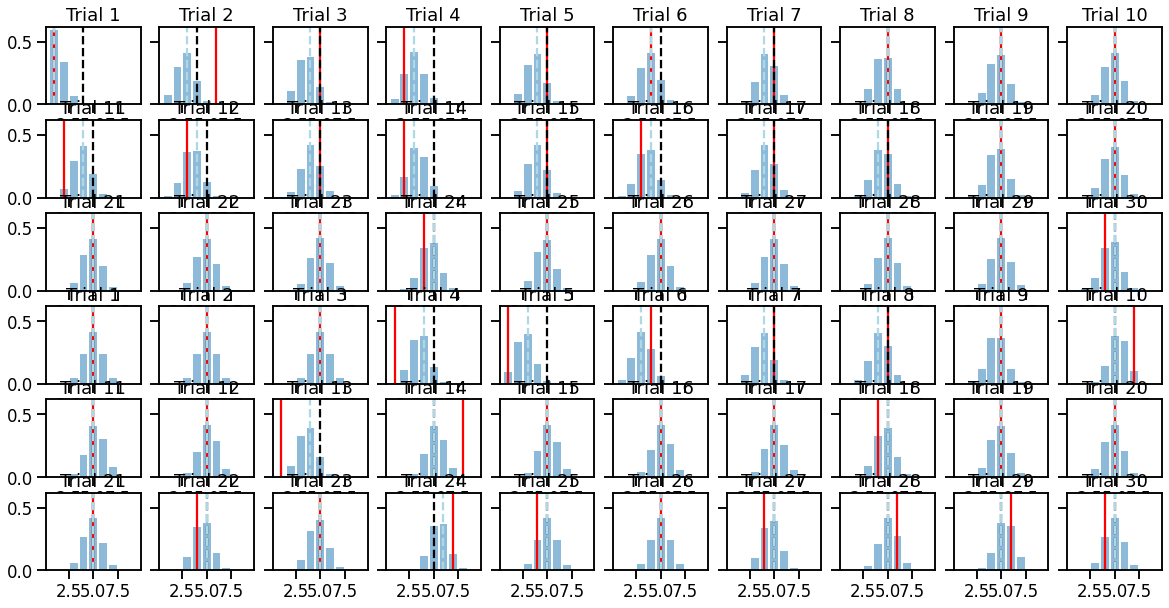

In [216]:
subset = sim_A.query('subID==40')
#for each trial, plot the predicted distribution and the actual partner step
plot_trial_predictions(subset)


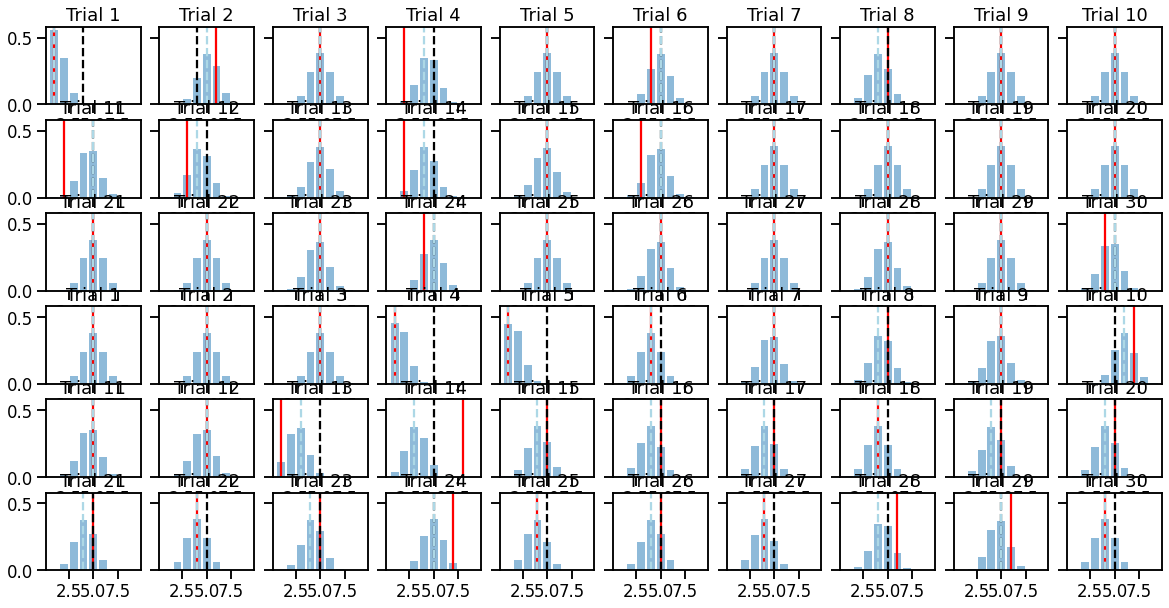

In [217]:
subset = sim_B.query('subID==40')
plot_trial_predictions(subset)

In [ ]:
# save
sim_A.to_csv(f"../model_fits/rl{folder}/simulated_predictions.csv", index=False)
sim_A.head()

In [218]:
sim_A.columns

Index(['subID', 'predatorType', 'trial', 'model_type', 'eta_used', 'mu0_used',
       'sigma_used', 'partnerStep_t', 'attack_t', 'player_partner_diff_t',
       'alpha_before', 'beta_before', 'mu_state_before', 'mu_pred',
       'prediction_sim', 'prediction_argmax', 'prediction_obs',
       'loglik_prediction_obs', 'p_square_1', 'p_square_2', 'p_square_3',
       'p_square_4', 'p_square_5', 'p_square_6', 'p_square_7', 'p_square_8',
       'p_square_9', 'partnerStep_next', 'delta'],
      dtype='object')

In [262]:
# compare predicted vs predicted step for each model
sim_A['model_prediction_error'] = np.abs(sim_A['prediction_obs'] - sim_A['prediction_argmax'])
sim_B['model_prediction_error'] = np.abs(sim_B['prediction_obs'] - sim_B['prediction_argmax'])
sim_C['model_prediction_error'] = np.abs(sim_C['prediction_obs'] - sim_C['prediction_argmax'])
sim_D['model_prediction_error'] = np.abs(sim_D['prediction_obs'] - sim_D['prediction_argmax']) 

# bar plot of partner error by model
avg_error = pd.DataFrame({  
    "scalar RW": sim_A.groupby("subID")["model_prediction_error"].mean(),
    "player partner diff": sim_B.groupby("subID")["model_prediction_error"].mean(),
    "player partner diff + attack": sim_C.groupby("subID")["model_prediction_error"].mean(),
    "win-stay-lose-shift": sim_D.groupby("subID")["model_prediction_error"].mean()
}).reset_index().melt(id_vars="subID", var_name="model", value_name="model_prediction_error")
avg_error.to_csv(f"../model_fits/rl_{folder}/avg_sim_prediction_error.csv")

## plot MSE

In [275]:
folder = 'conf'
if folder == 'conf':
    avg_error1 = pd.read_csv(f'../model_fits/rl_conf/avg_sim_prediction_error.csv')
    avg_error2 = pd.read_csv(f'../model_fits/rl_rep2/avg_sim_prediction_error.csv')
    avg_error2['subID'] = avg_error2['subID'] + 400
    avg_error = pd.concat([avg_error1, avg_error2])
elif folder == 'expl':
    avg_error = pd.read_csv(f'../model_fits/rl_expl/avg_sim_prediction_error.csv')

print(len(avg_error.subID.unique()))
avg_error.head()



514


,Unnamed: 0,subID,model,model_prediction_error
0,0,0,scalar RW,1.300000
1,1,1,scalar RW,1.100000
2,2,2,scalar RW,2.800000
3,3,3,scalar RW,2.016667
4,4,4,scalar RW,0.383333


/var/folders/pz/7dj8ydn13nl3v61r2ph397lh0000gn/T/ipykernel_54982/3652907700.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

scalar RW vs. player partner diff: Wilcoxon test (paired samples), P_val:5.163e-51 Stat=1.185e+04
scalar RW vs. player partner diff + attack: Wilcoxon test (paired samples), P_val:5.127e-75 Stat=4.286e+03
scalar RW vs. win-stay-lose-shift: Wilcoxon test (paired samples), P_val:6.280e-77 Stat=1.276e+03


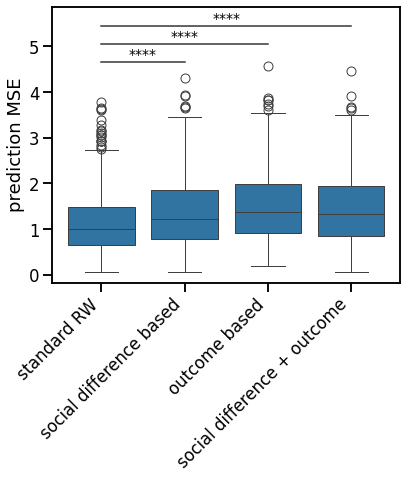

In [276]:

plt.figure(figsize=(6, 7))
ax = sns.boxplot(avg_error, x="model", y="model_prediction_error")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('prediction MSE')
ax.set_xlabel('')

# annotate significance on plot: use annotate package
from statannotations.Annotator import Annotator
pairs = [
    ("scalar RW", "player partner diff"),
    ("scalar RW", "player partner diff + attack"),
    ("scalar RW", "win-stay-lose-shift"),
]

annotator = Annotator(
    ax,
    pairs,
    data=avg_error,
    x="model",
    y="model_prediction_error"
)

annotator.configure(
    test="Wilcoxon",
    text_format="star",   # or "simple"
    loc="inside",
    verbose=2,
    fontsize=14,
    line_height=0
)

plt.xticks([0,1,2,3],
    ['standard RW', 'social difference based', 'outcome based', 'social difference + outcome'])
annotator.apply_and_annotate()
plt.tight_layout()
plt.savefig(f'../paper_figs/{folder}/add_prediction_model_sim_{folder}.png', 
            bbox_inches='tight', dpi=200)



(array([27., 38., 21., 30., 24., 20.,  8.,  5.,  8.,  5.,  5.,  8.,  0.,
         5.,  1.,  2.,  1.,  0.,  1.,  1.]),
 array([ 0.05      ,  1.07833333,  2.10666667,  3.135     ,  4.16333333,
         5.19166667,  6.22      ,  7.24833333,  8.27666667,  9.305     ,
        10.33333333, 11.36166667, 12.39      , 13.41833333, 14.44666667,
        15.475     , 16.50333333, 17.53166667, 18.56      , 19.58833333,
        20.61666667]),
 <BarContainer object of 20 artists>)

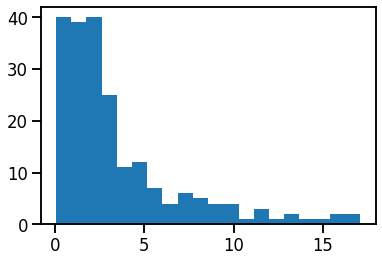

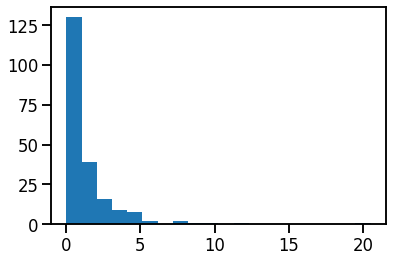

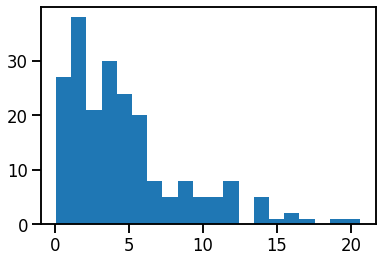

In [157]:
sim_df = sim_A
sim_df['mse'] = (sim_df['prediction_obs'] - sim_df['prediction_argmax']) ** 2
d = sim_df.groupby("subID")["mse"].mean()
plt.figure()
plt.hist(d, bins=20)

# between partner step and simulated prediction
sim_df['mse'] = (sim_df['partnerStep_t'] - sim_df['prediction_argmax']) ** 2
d = sim_df.groupby("subID")["mse"].mean()
plt.figure()
plt.hist(d, bins=20)

# between partner step and real prediction
sim_df['mse'] = (sim_df['partnerStep_t'] - sim_df['prediction_obs']) ** 2
d = sim_df.groupby("subID")["mse"].mean()
plt.figure()
plt.hist(d, bins=20)

# Supp Model Fits

In [448]:
folder='expl'
def read_model_df(mname, fname, folder = folder):
    if fname != '':
        fname = '_' + fname
    if folder == "conf":
        df = pd.read_csv(f'../model_fits/rl_rep2/{mname}{fname}.csv')
        df['subID']= df_flat['subID'] + 400
        df = pd.concat([pd.read_csv(f"../model_fits/rl_{folder}/{mname}{fname}.csv"), df])

    else:
        df = pd.read_csv(f"../model_fits/rl_{folder}/{mname}{fname}.csv")
        
    # print(len(df['subID'].unique()))
    return df

# mymodel = "lrflat_peppgFull_econ_ThetaGamma"
# # mymodel2 = "deltaWeightBlame"
# mymodel2 = "arbWeight_llh"
# # mname = f"{mymodel}_{mymodel2}_mserecal"
# mname = f"{mymodel}_{mymodel2}"

# GENRULE, CHOICERULE = mymodel.split("_")[0:2]
# print([GENRULE, CHOICERULE])

# params_df = read_model_df(mname, '', 'expl')
# params_df= params_df.rename({'nll': 'mse'}, axis=1)
# params_df['mse'] = params_df['mse'] * 90 # convert neg log likelihood to mse for AIC/BIC calculation

def mybic(nll, k, N = 176): #176 trials becuase we ignored the first trial for each predator
    return k * np.log(N) + 2 * nll

def myaic(nll, k, N = 176):
    return k * 2 +2 * nll

    
# params_df['bic'] = params_df['nll'].apply(lambda x: mybic(x, 5))
# params_df['aic'] = params_df['nll'].apply(lambda x: myaic(x, 5))

# print(len(params_df))

# print(np.mean(params_df['nll']))

# params_df.head()

if folder=='conf':
    df_group = pd.read_csv('../processed_data/parsed_group_rep2.csv')
    df_group['subID'] = df_group['subID'] + 400
    df_group = pd.concat([pd.read_csv('../processed_data/parsed_group_conf.csv'), df_group]).reset_index(drop=True)
else:
    df_group = pd.read_csv(f'../processed_data/parsed_group_{folder}.csv')

In [449]:
# mymodel = "lrhist_peppgFull_econ_ThetaGamma"
# # mymodel2 = "deltaWeightBlame"
# mymodel2 = "arbWeight_llh"
# mname = f"{mymodel}_{mymodel2}"
# mname2 = f"{mymodel}_{mymodel2}"


# params_df2 = read_model_df(mname2, '', 'expl')
# params_df2= params_df2.rename({'nll': 'mse'}, axis=1)
# print(np.mean(params_df2['mse']))

# print(ss.pearsonr(params_df['w'], params_df2['w']))
# print(ss.pearsonr(params_df['alpha'], params_df2['alpha']) )

In [450]:
# #show recovery
# mymodel = "lrflat_peppgFull_econ_ThetaGamma"
# mymodel2 = "arbWeight_llh"
# mname = f"{mymodel}_{mymodel2}"
# print(mname)


# rec_df = read_model_df(mname, 'recovery')
# params_df = read_model_df(mname, '')
# m = pd.merge(params_df, rec_df, on=['subID'])
# # # #if fit by sub:
# # rec_df['subID'] = rec_df['subID']-1
# # rec_df.head()
# print(m.head())

# sns.set_context('talk')
# m['gamma2_x'] = m['gamma_x'] * m['alpha_x']
# m['gamma2_y'] = m['gamma_y'] * m['alpha_y']
# print(len(m))
# col_names = {'alpha':r'learning rate $\alpha$',
#              'theta': r'risk $\theta$',
#              'gamma': r'discount $\gamma$',
#              'w':r'weight $w$'}
# fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# for i, col in enumerate(['alpha', 'theta', 'gamma', 'w']):
#     sns.regplot(data=m, x=col+'_x', y=col+'_y', ax=axes[i], scatter_kws={'s':30, 'alpha':0.2})
#     # axes[i].plot([axes[i].get_xlim()[0], axes[i].get_xlim()[1]], [axes[i].get_ylim()[0], axes[i].get_ylim()[1]], 
#     #              ls='--', lw=1.5)
#     #add title
#     # col = re.sub(r'\d+', '', col)
#     # axes[i].set_title(f"$\{col}$" if col!='w' else f"${col}$")
#     axes[i].set_title(col_names[col])
#     axes[i].set_xlabel('fitted')
#     axes[i].set_ylabel('recovered')
#     print(ss.pearsonr(m[col+'_x'], m[col+'_y']))


    
# plt.tight_layout()
# # if save:
# #     plt.savefig(f'../figs/{folder}/supp_recovery_{mymodel}_{mymodel2}_{folder}.png', 
# #                 bbox_inches='tight', dpi=200)

In [451]:
m1_list = [
        # "realPrediction_lrdecay2_peppg_econ_ThetaGamma",

        "learned_lrdecay_peppgFull_econ_ThetaGamma",
        "learned_lrflat_peppgFull_econ_ThetaGamma",
        "learned_lrhist_peppgFull_econ_ThetaGamma",
        "rollingAverage_lrdecay_peppgFull_econ_ThetaGamma",
        "rollingAverage_lrhist_peppgFull_econ_ThetaGamma",
        "rollingAverage_lrflat_peppgFull_econ_ThetaGamma",
        "realPrediction_lrdecay_peppgFull_econ_ThetaGamma",
        "realPrediction_lrhist_peppgFull_econ_ThetaGamma",
        "realPrediction_lrflat_peppgFull_econ_ThetaGamma",
        ]
m2_list = ["arbWeight_llh"] #"deltaWeight",

all_params_df = pd.DataFrame()

for mymodel in m1_list:
    for mymodel2 in m2_list:
        # try:
        params_df = read_model_df(f"{mymodel}_{mymodel2}", '')
        params_df['model_name'] = "_".join(mymodel.split("_")[:2])
        k = 4 if "asIfIdv" not in mymodel2 else 3
        num_trials = df_group.query('step_rt<8').groupby('subID', as_index=False)['trial'].count()
        params_df = pd.merge(params_df, num_trials)
        if 'nll' not in params_df.columns:
            params_df['nll'] = params_df['nll_idv'] + params_df['nll_grp']
        params_df['bic'] = params_df.apply(lambda row: mybic(row['nll'], k, 118+row['trial']), axis=1)
        params_df['aic'] = params_df.apply(lambda row: myaic(row['nll'], k, 118+row['trial']), axis=1)
        all_params_df = pd.concat([all_params_df, params_df])
        # except:
        #     pass

print(all_params_df['model_name'].unique())
print(len(all_params_df['subID'].unique()))
all_params_df['model_name'] = all_params_df['model_name'].str.replace(
    'lrhist', 'lrlinear', regex=False
)
# if min(all_params_df['subID'])==1:
#     all_params_df['subID'] = all_params_df['subID'] - 1
# print(f"{len(params_df.subID.unique())} subs with avg nll = {np.mean(params_df.loc[params_df.nll!=np.inf]['nll'])}")
all_params_df.head()



['learned_lrdecay' 'learned_lrflat' 'learned_lrhist'
 'rollingAverage_lrdecay' 'rollingAverage_lrhist' 'rollingAverage_lrflat'
 'realPrediction_lrdecay' 'realPrediction_lrhist' 'realPrediction_lrflat']
250


,subID,alpha,theta,gamma,w,nll_idv,nll_grp,model_name,trial,nll,bic,aic
0,18,0.52,0.87,0.27,-0.26,321.568112,138.919759,learned_lrdecay,59,460.487871,941.680341,928.975742
1,14,0.57,0.65,0.56,-0.36,213.485713,119.710371,learned_lrdecay,60,333.196085,687.119303,674.392169
2,4,0.78,0.51,0.68,0.44,171.081866,124.229602,learned_lrdecay,59,295.311469,611.327537,598.622938
3,0,1.00,0.64,0.80,0.35,182.664414,87.810760,learned_lrdecay,60,270.475174,561.677482,548.950348
4,2,1.00,0.88,0.81,0.44,208.074351,93.447107,learned_lrdecay,60,301.521458,623.770050,611.042916


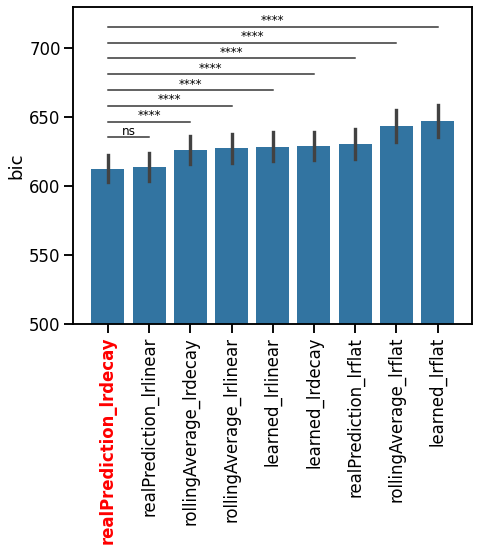

In [452]:
order = all_params_df.groupby('model_name')['bic'].mean().sort_values().index

from statannotations.Annotator import Annotator
from scipy.stats import ttest_rel
import seaborn as sns
import matplotlib.pyplot as plt

target_model = "realPrediction_lrdecay"

order = (
    all_params_df.groupby("model_name")["bic"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(7, 8))

sns.barplot(
    data=all_params_df,
    y="bic",
    x="model_name",
    order=order,
    errorbar="se",
    ax=ax
)

ax.set_ylim(bottom=500)
ax.tick_params(axis="x", rotation=90)

for label in ax.get_xticklabels():
    if label.get_text() == target_model:
        label.set_color("red")
        label.set_fontweight("bold")

# compare target model against every other model
pairs = [
    (target_model, model)
    for model in order
    if model != target_model
]

annotator = Annotator(
    ax,
    pairs,
    data=all_params_df,
    x="model_name",
    y="bic",
    order=order
)

annotator.configure(
    test="t-test_paired",
    text_format="star",
    loc="inside",
    comparisons_correction="bonferroni",
    verbose=0,
    line_height = 0,
    line_offset=0.005,
    text_offset=0.005,
    fontsize=12
)

annotator.apply_and_annotate()

plt.ylim(bottom=500)
plt.xticks(rotation=90)
plt.xlabel("")

plt.tight_layout()
plt.savefig(f"../paper_figs/{folder}/supp_model_comparison_{folder}.png", dpi=200)
plt.show()

In [453]:
def plot_corr_matrix(vname):
    plt.figure(figsize=(8,7))
    df_wide = all_params_df.pivot(index='subID', columns='model_name', values=vname)
    corr_matrix = df_wide.corr()
    # print(corr_matrix)

    # get upper triangle (excluding diagonal)
    vals = corr_matrix.values
    mean_corr = vals[np.triu_indices_from(vals, k=1)].mean()
    # print(mean_corr)


    ax = sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
    cbar = ax.collections[0].colorbar
    cbar.set_label(f'{vname} correlation', rotation=270, labelpad=20)
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()
    # plt.show()

In [436]:
# plt.scatter(all_params_df.query('model_name == "learned_lrdecay_peppgFull_econ_ThetaGamma"')['w'],
#             all_params_df.query('model_name == "realPrediction_lrdecay_peppgFull_econ_ThetaGamma"')['w'])

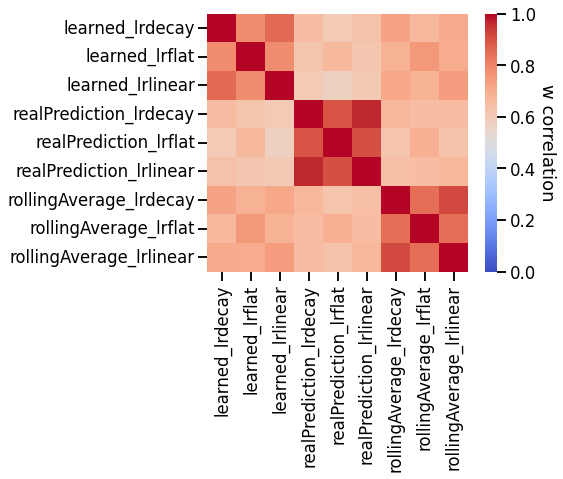

In [437]:
vname = 'w'
plot_corr_matrix(vname)

plt.savefig(f"../paper_figs/{folder}/supp_model_w_correlation_{folder}.png", dpi=200)
plt.show()

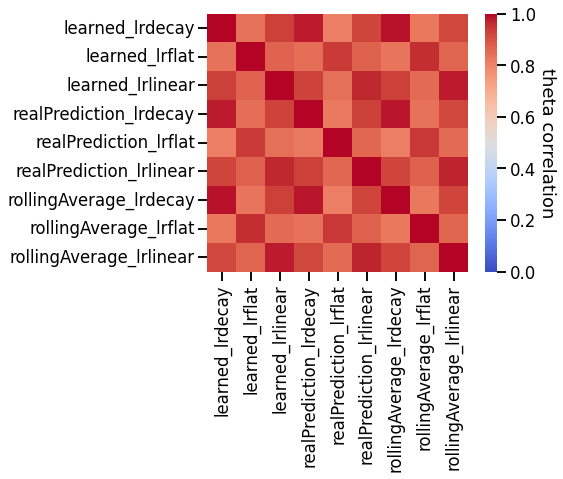

In [438]:
vname = 'theta'
plot_corr_matrix(vname)

plt.savefig(f"../paper_figs/{folder}/supp_model_theta_correlation_{folder}.png", dpi=200)
plt.show()